# Cell 1 - Load & Combine Order Book Data

In [ ]:

import pandas as pd
import numpy as np
import os
import random

random.seed(3888)
data_path = 'Optiver_additional_data'  

book_cols = [
    "stock_id", "time_id", "seconds_in_bucket",
    "bid_price1", "ask_price1", "bid_price2", "ask_price2",
    "bid_size1",  "ask_size1",  "bid_size2",  "ask_size2",
]

print("Loading order_book_feature.csv...")
ob_feature = pd.read_csv(
    os.path.join(data_path, "order_book_feature.csv"),
    sep="\t",
    usecols=book_cols,
    dtype={
        "stock_id": np.int32,
        "time_id":  np.int32,
        "seconds_in_bucket": np.float32,
        "bid_price1": np.float32, "ask_price1": np.float32,
        "bid_price2": np.float32, "ask_price2": np.float32,
        "bid_size1":  np.float32, "ask_size1":  np.float32,
        "bid_size2":  np.float32, "ask_size2":  np.float32,
    }
)
print(f"  Feature shape : {ob_feature.shape}")
print(f"  seconds range : {ob_feature['seconds_in_bucket'].min():.0f} – {ob_feature['seconds_in_bucket'].max():.0f}")
print(f"  Stocks        : {ob_feature['stock_id'].nunique()}")
print(f"  Time_ids      : {ob_feature['time_id'].nunique()}")
print(f"  Memory        : {ob_feature.memory_usage(deep=True).sum() / 1e6:.1f} MB")

print("\nLoading order_book_target.csv...")
ob_target = pd.read_csv(
    os.path.join(data_path, "order_book_target.csv"),
    sep="\t",
    usecols=book_cols,
    dtype={
        "stock_id": np.int32,
        "time_id":  np.int32,
        "seconds_in_bucket": np.float32,
        "bid_price1": np.float32, "ask_price1": np.float32,
        "bid_price2": np.float32, "ask_price2": np.float32,
        "bid_size1":  np.float32, "ask_size1":  np.float32,
        "bid_size2":  np.float32, "ask_size2":  np.float32,
    }
)
print(f"  Target shape  : {ob_target.shape}")
print(f"  seconds range : {ob_target['seconds_in_bucket'].min():.0f} – {ob_target['seconds_in_bucket'].max():.0f}")

# Combine 
print("\nCombining...")
order_book = pd.concat([ob_feature, ob_target], ignore_index=True)
del ob_feature, ob_target   # free memory immediately


order_book["seconds_in_bucket"] = order_book["seconds_in_bucket"].astype(np.int32)

order_book = order_book.sort_values(
    ["stock_id", "time_id", "seconds_in_bucket"]
).reset_index(drop=True)


print(f"\n── Combined order_book ──────────────────────────────")
print(f"  Shape         : {order_book.shape}")
print(f"  Columns       : {list(order_book.columns)}")
print(f"  Stocks        : {order_book['stock_id'].nunique()}  → {sorted(order_book['stock_id'].unique())}")
print(f"  Time_ids      : {order_book['time_id'].nunique()}  (min={order_book['time_id'].min()}, max={order_book['time_id'].max()})")
print(f"  seconds range : {order_book['seconds_in_bucket'].min()} – {order_book['seconds_in_bucket'].max()}  (expect 0–3599)")
print(f"  Memory        : {order_book.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Missing values:\n{order_book.isnull().sum()}")

# Verify the feature/target halves don't overlap on seconds
feature_secs = order_book[order_book["seconds_in_bucket"] <= 1799]["seconds_in_bucket"]
target_secs  = order_book[order_book["seconds_in_bucket"] >= 1800]["seconds_in_bucket"]
print(f"\n  Feature half rows : {len(feature_secs):,}  (seconds 0–1799)")
print(f"  Target half rows  : {len(target_secs):,}  (seconds 1800–3599)")
assert len(feature_secs) + len(target_secs) == len(order_book), "Row count mismatch!"

# Check one stock/time_id to confirm continuity
sample_stock   = order_book["stock_id"].iloc[0]
sample_time_id = order_book[order_book["stock_id"] == sample_stock]["time_id"].iloc[0]
sample = order_book[
    (order_book["stock_id"] == sample_stock) &
    (order_book["time_id"]  == sample_time_id)
]
print(f"\n  Sample stock={sample_stock}, time_id={sample_time_id}:")
print(f"    Rows           : {len(sample)}")
print(f"    seconds range  : {sample['seconds_in_bucket'].min()} – {sample['seconds_in_bucket'].max()}")
print(f"    First 3 rows:\n{sample.head(3).to_string()}")
print(f"    Rows around the 1800s boundary:")
print(sample[sample["seconds_in_bucket"].between(1797, 1803)].to_string())

print("\n✓ Step 1 complete — order_book ready for processing")

Loading order_book_feature.csv...
  Feature shape : (17646119, 11)
  seconds range : 0 – 1799
  Stocks        : 10
  Time_ids      : 1152
  Memory        : 776.4 MB

Loading order_book_target.csv...
  Target shape  : (17911332, 11)
  seconds range : 1800 – 3599

Combining...

── Combined order_book ──────────────────────────────
  Shape         : (35557451, 11)
  Columns       : ['stock_id', 'time_id', 'seconds_in_bucket', 'bid_price1', 'ask_price1', 'bid_price2', 'ask_price2', 'bid_size1', 'ask_size1', 'bid_size2', 'ask_size2']
  Stocks        : 10  → [np.int32(8382), np.int32(9323), np.int32(22675), np.int32(22729), np.int32(22753), np.int32(22771), np.int32(22951), np.int32(48219), np.int32(50200), np.int32(104919)]
  Time_ids      : 1158  (min=6, max=1199)
  seconds range : 0 – 3599  (expect 0–3599)
  Memory        : 1564.5 MB
  Missing values:
stock_id             0
time_id              0
seconds_in_bucket    0
bid_price1           0
ask_price1           0
bid_price2           0
a

In [ ]:

# 1. How widespread are duplicates?
dupe_mask = order_book.duplicated(subset=["stock_id", "time_id", "seconds_in_bucket"], keep=False)
n_dupes = dupe_mask.sum()
print(f"Total rows with duplicate (stock_id, time_id, seconds_in_bucket): {n_dupes:,}")
print(f"As % of total rows: {100 * n_dupes / len(order_book):.1f}%")

# 2. Are duplicates only in the target file (seconds >= 1800)?
dupes = order_book[dupe_mask]
print(f"\nDuplicate rows by half:")
print(f"  Feature half (0–1799)  : {(dupes['seconds_in_bucket'] <= 1799).sum():,}")
print(f"  Target half  (1800–3599): {(dupes['seconds_in_bucket'] >= 1800).sum():,}")

# 3. Are the duplicate rows identical (same prices/sizes)?
true_dupes = order_book.duplicated(keep=False)  # all columns
print(f"\nRows duplicated on ALL columns (truly identical): {true_dupes.sum():,}")
print(f"Rows duplicated only on key (different prices):   {n_dupes - true_dupes.sum():,}")

# 4. Sample a non-boundary duplicate to confirm pattern
print("\nSample duplicates from seconds 1850–1900:")
mid_dupes = dupes[dupes["seconds_in_bucket"].between(1850, 1900)].head(6)
print(mid_dupes.to_string())

# 5. Check feature half for duplicates
print("\nSample duplicates from feature half (0–1799):")
feat_dupes = dupes[dupes["seconds_in_bucket"] <= 1799].head(6)
if len(feat_dupes) == 0:
    print("  None — duplicates only in target half ✓")
else:
    print(feat_dupes.to_string())

Total rows with duplicate (stock_id, time_id, seconds_in_bucket): 193,468
As % of total rows: 0.5%

Duplicate rows by half:
  Feature half (0–1799)  : 0
  Target half  (1800–3599): 193,468


KeyboardInterrupt: 

# Cell 2 - Cleaning + preprocess + forward fill

In [ ]:

import os

os.makedirs("tech_processed", exist_ok=True)

book_cols = [
    "bid_price1", "ask_price1", "bid_price2", "ask_price2",
    "bid_size1",  "ask_size1",  "bid_size2",  "ask_size2",
]

# Drop exact duplicates
print(f"Rows before dedup : {len(order_book):,}")
order_book = order_book.drop_duplicates().reset_index(drop=True)
print(f"Rows after dedup  : {len(order_book):,}")
print(f"Dropped           : {35557451 - len(order_book):,} duplicate rows")

# Compute WAP and spread (pre-fill, for reference) 

order_book["wap"] = (
    (order_book["bid_price1"] * order_book["ask_size1"] +
     order_book["ask_price1"] * order_book["bid_size1"])
    / (order_book["bid_size1"] + order_book["ask_size1"])
)
order_book["bid_ask_spread"] = order_book["ask_price1"] / order_book["bid_price1"] - 1

print(f"\nPre-fill WAP sample (first 3 rows):")
print(order_book[["stock_id", "time_id", "seconds_in_bucket", "wap", "bid_ask_spread"]].head(3).to_string())

#  Step 2c: Process each stock — grid reconstruction + forward-fill 

def process_tech_stock(df_stock):
    """
    For one stock (all time_ids):
    1. Expand to full 0–3599 second grid per time_id
    2. Forward-fill order book columns within each time_id
    3. Recompute WAP and spread from filled values
    4. Compute log returns
    """
    stock_id     = df_stock["stock_id"].iloc[0]
    all_time_ids = df_stock["time_id"].unique()


    full_index = pd.MultiIndex.from_product(
        [all_time_ids, np.arange(0, 3600)],
        names=["time_id", "seconds_in_bucket"]
    )
    df_stock = (
        df_stock
        .set_index(["time_id", "seconds_in_bucket"])
        .reindex(full_index)
        .reset_index()
    )
    df_stock["stock_id"] = stock_id


    df_stock[book_cols] = (
        df_stock.groupby("time_id")[book_cols]
        .transform(lambda x: x.ffill())
    )

    df_stock["wap_raw"] = (
        (df_stock["bid_price1"] * df_stock["ask_size1"] +
        df_stock["ask_price1"] * df_stock["bid_size1"])
        / (df_stock["bid_size1"] + df_stock["ask_size1"])
    )

    df_stock["bid_ask_spread"] = df_stock["ask_price1"] / df_stock["bid_price1"] - 1


    session_first_wap = df_stock.groupby("time_id")["wap_raw"].transform("first")
    df_stock["wap"] = df_stock["wap_raw"] / session_first_wap


    df_stock["log_return"] = (
        df_stock.groupby("time_id")["wap"]
        .transform(lambda x: np.log(x).diff().fillna(0))
    )

    df_stock = df_stock.dropna(subset=book_cols).reset_index(drop=True)

    


    float_cols = df_stock.select_dtypes(include="float64").columns
    df_stock[float_cols] = df_stock[float_cols].astype(np.float32)

    return df_stock


stock_ids = sorted(order_book["stock_id"].unique())
print(f"\nProcessing {len(stock_ids)} stocks: {stock_ids}")

processed_stocks = {}

for stock_id in stock_ids:
    df_s  = order_book[order_book["stock_id"] == stock_id].copy()
    result = process_tech_stock(df_s)
    result.to_parquet(f"tech_processed/stock_{stock_id}.parquet", index=False)
    processed_stocks[stock_id] = result.shape
    print(f"  Stock {stock_id:>6}: {result.shape[0]:>8,} rows  |  "
          f"time_ids={result['time_id'].nunique()}  |  "
          f"seconds {result['seconds_in_bucket'].min()}–{result['seconds_in_bucket'].max()}")
    del result

print(f"\n✓ Saved {len(stock_ids)} parquet files to tech_processed/")


sample_stock_id = stock_ids[0]
sample = pd.read_parquet(f"tech_processed/stock_{sample_stock_id}.parquet")
sample_tid      = sample["time_id"].iloc[0]
sample_session  = sample[sample["time_id"] == sample_tid]

print(f"\n── Sanity check: stock={sample_stock_id}, time_id={sample_tid} ──")
print(f"  Session rows     : {len(sample_session)}  (expect close to 3600)")
print(f"  seconds range    : {sample_session['seconds_in_bucket'].min()} – {sample_session['seconds_in_bucket'].max()}")
print(f"  WAP nulls        : {sample_session['wap'].isna().sum()}")
print(f"  Spread nulls     : {sample_session['bid_ask_spread'].isna().sum()}")
print(f"  Log return nulls : {sample_session['log_return'].isna().sum()}")
print(f"  WAP range        : {sample_session['wap'].min():.4f} – {sample_session['wap'].max():.4f}")
print(f"\n  First 5 rows:")
print(sample_session[["seconds_in_bucket","wap","bid_ask_spread","log_return"]].head(5).to_string())
print(f"\n  Rows around the 1800s boundary:")
boundary = sample_session[sample_session["seconds_in_bucket"].between(1797, 1803)]
print(boundary[["seconds_in_bucket","wap","bid_ask_spread","log_return"]].to_string())

Rows before dedup : 35,557,451
Rows after dedup  : 35,460,717
Dropped           : 96,734 duplicate rows

Pre-fill WAP sample (first 3 rows):
   stock_id  time_id  seconds_in_bucket         wap  bid_ask_spread
0      8382        6               1800  740.159973        0.000351
1      8382        6               1801  740.280823        0.000324
2      8382        6               1802  740.290771        0.000405

Processing 10 stocks: [np.int32(8382), np.int32(9323), np.int32(22675), np.int32(22729), np.int32(22753), np.int32(22771), np.int32(22951), np.int32(48219), np.int32(50200), np.int32(104919)]
  Stock   8382: 4,157,726 rows  |  time_ids=1158  |  seconds 0–3599
  Stock   9323: 4,157,803 rows  |  time_ids=1158  |  seconds 0–3599
  Stock  22675: 4,157,617 rows  |  time_ids=1158  |  seconds 0–3599
  Stock  22729: 4,157,326 rows  |  time_ids=1158  |  seconds 0–3599
  Stock  22753: 4,157,672 rows  |  time_ids=1158  |  seconds 0–3599
  Stock  22771: 4,157,457 rows  |  time_ids=1158  |  s

In [ ]:

ob_feat_tids = set(
    pd.read_csv(
        os.path.join(data_path, "order_book_feature.csv"),
        sep="\t", usecols=["time_id"]
    )["time_id"].unique()
)
ob_targ_tids = set(
    pd.read_csv(
        os.path.join(data_path, "order_book_target.csv"),
        sep="\t", usecols=["time_id"]
    )["time_id"].unique()
)

only_in_feature = ob_feat_tids - ob_targ_tids
only_in_target  = ob_targ_tids - ob_feat_tids
in_both         = ob_feat_tids & ob_targ_tids

print(f"time_ids in feature file only : {len(only_in_feature)}")
print(f"time_ids in target file only  : {len(only_in_target)}")
print(f"time_ids in both files        : {len(in_both)}")
print(f"\nSample time_ids only in feature : {sorted(only_in_feature)[:10]}")
print(f"Sample time_ids only in target  : {sorted(only_in_target)[:10]}")


print("\nPer-stock time_id coverage check:")
for stock_id in sorted(order_book["stock_id"].unique()):
    df_s = order_book[order_book["stock_id"] == stock_id]
    feat_tids = set(df_s[df_s["seconds_in_bucket"] <= 1799]["time_id"].unique())
    targ_tids = set(df_s[df_s["seconds_in_bucket"] >= 1800]["time_id"].unique())
    only_feat = feat_tids - targ_tids
    only_targ = targ_tids - feat_tids
    both      = feat_tids & targ_tids
    print(f"  Stock {stock_id:>6}: both={len(both):4d}  only_feature={len(only_feat):4d}  only_target={len(only_targ):4d}")


time_ref = pd.read_csv(os.path.join(data_path, "time_id_reference.csv"))
print(f"\ntime_id_reference shape: {time_ref.shape}")
print(f"time_id range in reference: {time_ref['time_id'].min()} – {time_ref['time_id'].max()}")

if only_in_target:
    print(f"\ntime_id_reference rows for target-only time_ids (first 10):")
    print(time_ref[time_ref["time_id"].isin(list(only_in_target)[:10])].to_string())

if only_in_feature:
    print(f"\ntime_id_reference rows for feature-only time_ids (first 10):")
    print(time_ref[time_ref["time_id"].isin(list(only_in_feature)[:10])].to_string())

time_ids in feature file only : 0
time_ids in target file only  : 6
time_ids in both files        : 1152

Sample time_ids only in feature : []
Sample time_ids only in target  : [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]

Per-stock time_id coverage check:
  Stock   8382: both=1152  only_feature=   0  only_target=   6
  Stock   9323: both=1152  only_feature=   0  only_target=   6
  Stock  22675: both=1152  only_feature=   0  only_target=   6
  Stock  22729: both=1152  only_feature=   0  only_target=   6
  Stock  22753: both=1152  only_feature=   0  only_target=   6
  Stock  22771: both=1152  only_feature=   0  only_target=   6
  Stock  22951: both=1152  only_feature=   0  only_target=   6
  Stock  48219: both=1152  only_feature=   0  only_target=   6
  Stock  50200: both=1152  only_feature=   0  only_target=   6
  Stock 104919: both=1152  only_feature=   0  only_target=   6

time_id_reference shape: (1188, 3)
time_id range in reference: 12 – 1199

ti

# Cell 3 - Bucket Aaggregation, RV + Target

In [ ]:

import glob

ORPHAN_TIDS  = {6, 7, 8, 9, 10, 11}   # target-half only, no feature data
BUCKET_SIZE  = 30                       # seconds — must match anonymous pipeline

def realised_volatility(log_returns):
    return np.sqrt(np.nansum(log_returns ** 2))

def aggregate_to_buckets(df_stock):
    """
    Takes a fully grid-reconstructed, forward-filled stock DataFrame
    and produces one row per (stock_id, time_id, bucket).
    """

    df_stock = df_stock[~df_stock["time_id"].isin(ORPHAN_TIDS)].copy()

    # Assign bucket number from seconds
    df_stock["bucket"] = (df_stock["seconds_in_bucket"] // BUCKET_SIZE).astype(int)


    #  Aggregate features per bucket
    agg = (
        df_stock.groupby(["stock_id", "time_id", "bucket"])
        .agg(
            wap_last       = ("wap",           "last"),
            wap_mean       = ("wap",           "mean"),
            spread_mean    = ("bid_ask_spread", "mean"),
            spread_max     = ("bid_ask_spread", "max"),
            log_return_sum = ("log_return",    "sum"),
            log_return_std = ("log_return",    "std"),
            n_obs          = ("wap",           "count"),
        )
        .reset_index()
    )

    #  Realised volatility per bucket 
    rv = (
        df_stock.groupby(["stock_id", "time_id", "bucket"])["log_return"]
        .apply(realised_volatility)
        .reset_index()
        .rename(columns={"log_return": "realised_volatility"})
    )

    features = agg.merge(rv, on=["stock_id", "time_id", "bucket"], how="left")

    #  Target = next bucket's RV 
    features = features.sort_values(
        ["stock_id", "time_id", "bucket"]
    ).reset_index(drop=True)

    features["target_rv"] = (
        features.groupby(["stock_id", "time_id"])["realised_volatility"]
        .shift(-1)
    )
    features = features.dropna(subset=["target_rv"]).reset_index(drop=True)

    features["bucket"] = features["bucket"] + 1
    # Now buckets run 1–119 (the 120th bucket is dropped — it had no target)

    # Downcast
    float_cols = features.select_dtypes(include="float64").columns
    features[float_cols] = features[float_cols].astype(np.float32)

    return features


# ── Run for all 10 tech stocks ────────────────────────────────────────────────
os.makedirs("tech_features", exist_ok=True)

stock_ids   = sorted([
    int(f.split("stock_")[1].replace(".parquet", ""))
    for f in glob.glob("tech_processed/stock_*.parquet")
])

all_features = []

for stock_id in stock_ids:
    df_s   = pd.read_parquet(f"tech_processed/stock_{stock_id}.parquet")
    result = aggregate_to_buckets(df_s)
    result.to_parquet(f"tech_features/stock_{stock_id}.parquet", index=False)
    all_features.append(result)

    print(f"  Stock {stock_id:>6}: {len(result):>8,} rows  |  "
          f"time_ids={result['time_id'].nunique()}  |  "
          f"buckets {result['bucket'].min()}–{result['bucket'].max()}  |  "
          f"n_obs per bucket: min={result['n_obs'].min():.0f} max={result['n_obs'].max():.0f}")
    del df_s

# ── Combine into single tech_data DataFrame ───────────────────────────────────
tech_data = pd.concat(all_features, ignore_index=True)
del all_features

tech_data.to_parquet("tech_data.parquet", index=False)

print(f"\n✓ Saved tech_data.parquet")
print(f"\n── tech_data summary ────────────────────────────────────────")
print(f"  Shape         : {tech_data.shape}")
print(f"  Columns       : {list(tech_data.columns)}")
print(f"  Stocks        : {sorted(tech_data['stock_id'].unique())}")
print(f"  Time_ids      : {tech_data['time_id'].nunique()}  "
      f"(min={tech_data['time_id'].min()}, max={tech_data['time_id'].max()})")
print(f"  Buckets       : {tech_data['bucket'].min()}–{tech_data['bucket'].max()}  "
      f"(expect 1–119)")
print(f"  Missing values:\n{tech_data.isnull().sum()}")

#  Compare distributions against anonymous data 
print(f"\n── Distribution comparison ──────────────────────────────────")
anon = pd.read_parquet("seen_data.parquet")  

for col in ["realised_volatility", "target_rv", "spread_mean", "wap_mean"]:
    a_mean, a_std = anon[col].mean(),      anon[col].std()
    t_mean, t_std = tech_data[col].mean(), tech_data[col].std()
    print(f"\n  {col}:")
    print(f"    Anonymous : mean={a_mean:.6f}  std={a_std:.6f}")
    print(f"    Tech      : mean={t_mean:.6f}  std={t_std:.6f}")
    print(f"    Ratio     : {t_mean/a_mean:.2f}x")

sample_sid = stock_ids[0]
sample_tid = tech_data[tech_data["stock_id"] == sample_sid]["time_id"].iloc[1]
session    = tech_data[
    (tech_data["stock_id"] == sample_sid) &
    (tech_data["time_id"]  == sample_tid)
]
print(f"\n── Full session check: stock={sample_sid}, time_id={sample_tid} ──")
print(f"  Rows (expect 119) : {len(session)}")
print(f"  Bucket range      : {session['bucket'].min()}–{session['bucket'].max()}")
print(f"  n_obs per bucket  : {session['n_obs'].unique()}  (expect [30])")
print(f"\n  First 5 buckets:")
print(session[["bucket","wap_mean","spread_mean","realised_volatility","target_rv"]].head(5).to_string())
print(f"\n  Last 5 buckets:")
print(session[["bucket","wap_mean","spread_mean","realised_volatility","target_rv"]].tail(5).to_string())

  Stock   8382:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=28 max=30
  Stock   9323:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=29 max=30
  Stock  22675:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=26 max=30
  Stock  22729:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=14 max=30
  Stock  22753:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=24 max=30
  Stock  22771:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=21 max=30
  Stock  22951:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=28 max=30
  Stock  48219:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=18 max=30
  Stock  50200:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bucket: min=29 max=30
  Stock 104919:  137,088 rows  |  time_ids=1152  |  buckets 1–119  |  n_obs per bu

# Cell 4 - Temporal Features + Model Evalutaion

In [ ]:
#  Cell 4 — Temporal Features 

import joblib
import numpy as np
import pandas as pd

EPS = 1e-5

base_features = [
    'wap_mean', 'wap_last', 'spread_mean', 'spread_max',
    'log_return_sum', 'log_return_std', 'realised_volatility',
]
target = 'target_rv'

def add_temporal_features(df):
    df = df.copy().sort_values(['stock_id', 'time_id', 'bucket']).reset_index(drop=True)


    df['_gid'] = df.groupby(['stock_id', 'time_id'], sort=False).ngroup()
    grp = df.groupby('_gid', sort=False)

    #  SHORT 
    df['rv_lag2']          = grp['realised_volatility'].shift(1)
    df['rv_lag3']          = grp['realised_volatility'].shift(2)
    df['spread_lag2']      = grp['spread_mean'].shift(1)
    df['spread_lag3']      = grp['spread_mean'].shift(2)
    df['logret_lag2']      = grp['log_return_sum'].shift(1)
    df['rv_delta']         = grp['realised_volatility'].diff()
    df['rv_rollmean3']     = grp['realised_volatility'].transform(
                                 lambda x: x.rolling(3, min_periods=2).mean())
    df['spread_rollmean3'] = grp['spread_mean'].transform(
                                 lambda x: x.rolling(3, min_periods=2).mean())

    short_features = [
        'rv_lag2', 'rv_lag3', 'spread_lag2', 'spread_lag3',
        'logret_lag2', 'rv_delta', 'rv_rollmean3', 'spread_rollmean3',
    ]

    #  MEDIUM 
    df['rv_lag5']          = grp['realised_volatility'].shift(4)
    df['spread_lag5']      = grp['spread_mean'].shift(4)
    df['logret_lag5']      = grp['log_return_sum'].shift(4)
    df['rv_momentum5']     = df['realised_volatility'] - df['rv_lag5']
    df['rv_rollmean5']     = grp['realised_volatility'].transform(
                                 lambda x: x.rolling(5, min_periods=3).mean())
    df['rv_rollstd5']      = grp['realised_volatility'].transform(
                                 lambda x: x.rolling(5, min_periods=3).std())
    df['spread_rollmean5'] = grp['spread_mean'].transform(
                                 lambda x: x.rolling(5, min_periods=3).mean())
    df['rv_ratio5']        = df['realised_volatility'] / (df['rv_rollmean5'] + EPS)
    df['rv_above_mean5']   = (df['realised_volatility'] > df['rv_rollmean5']).astype(int)

    medium_features = [
        'rv_lag5', 'spread_lag5', 'logret_lag5', 'rv_momentum5',
        'rv_rollmean5', 'rv_rollstd5', 'spread_rollmean5',
        'rv_ratio5', 'rv_above_mean5',
    ]

    #  LONG 
    df['rv_lag10']          = grp['realised_volatility'].shift(9)
    df['spread_lag10']      = grp['spread_mean'].shift(9)
    df['rv_momentum10']     = df['realised_volatility'] - df['rv_lag10']
    df['rv_rollmean10']     = grp['realised_volatility'].transform(
                                  lambda x: x.rolling(10, min_periods=6).mean())
    df['rv_rollstd10']      = grp['realised_volatility'].transform(
                                  lambda x: x.rolling(10, min_periods=6).std())
    df['spread_rollmean10'] = grp['spread_mean'].transform(
                                  lambda x: x.rolling(10, min_periods=6).mean())
    df['rv_ratio10']        = df['realised_volatility'] / (df['rv_rollmean10'] + EPS)
    df['rv_above_mean10']   = (df['realised_volatility'] > df['rv_rollmean10']).astype(int)

    long_features = [
        'rv_lag10', 'spread_lag10', 'rv_momentum10',
        'rv_rollmean10', 'rv_rollstd10', 'spread_rollmean10',
        'rv_ratio10', 'rv_above_mean10',
    ]

    df_short  = df.dropna(subset=short_features).reset_index(drop=True)
    df_medium = df.dropna(subset=short_features + medium_features).reset_index(drop=True)
    df_long   = df.dropna(subset=short_features + medium_features + long_features).reset_index(drop=True)

    for d in [df_short, df_medium, df_long]:
        d.drop(columns=['_gid'], inplace=True, errors='ignore')

    return df_short, df_medium, df_long, short_features, medium_features, long_features


#  Run 
print("Computing temporal features...")
tech_base = tech_data.dropna(subset=base_features + [target]).reset_index(drop=True)

tech_short, tech_medium, tech_long, \
short_f, medium_f, long_f = add_temporal_features(tech_base)

# Build full feature lists exactly as Notebook 2 does
features_short  = base_features + short_f
features_medium = base_features + short_f + medium_f
features_long   = base_features + short_f + medium_f + long_f
har_features    = ['realised_volatility', 'rv_rollmean5', 'rv_rollmean10']

print(f"\nRows per horizon:")
print(f"  Base   : {len(tech_base):>8,}")
print(f"  Short  : {len(tech_short):>8,}")
print(f"  Medium : {len(tech_medium):>8,}")
print(f"  Long   : {len(tech_long):>8,}")

print(f"\nFeature counts:")
print(f"  Base   : {len(base_features):>3}")
print(f"  Short  : {len(features_short):>3}  (expect 15)")
print(f"  Medium : {len(features_medium):>3}  (expect 24)")
print(f"  Long   : {len(features_long):>3}  (expect 32)")

# Verify against a saved model
lr_long = joblib.load('models/lr_long.joblib')
status  = '✓' if lr_long.n_features_in_ == len(features_long) else '✗ MISMATCH'
print(f"\nLR Long expects {lr_long.n_features_in_} features, "
      f"we built {len(features_long)} → {status}")

Computing temporal features...

Rows per horizon:
  Base   : 1,370,880
  Short  : 1,347,840
  Medium : 1,324,800
  Long   : 1,267,200

Feature counts:
  Base   :   7
  Short  :  15  (expect 15)
  Medium :  24  (expect 24)
  Long   :  32  (expect 32)

LR Long expects 32 features, we built 32 → ✓


# Cell 5 - Per-stock Evaluation across all models 

In [ ]:

import joblib
import numpy as np
import pandas as pd

EPS = 1e-5

def _clean(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask   = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.maximum(y_true[mask], EPS), np.maximum(y_pred[mask], EPS)

def rmse(y_true, y_pred):
    y_true, y_pred = _clean(y_true, y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def rmspe(y_true, y_pred):
    y_true, y_pred = _clean(y_true, y_pred)
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

def qlike(y_true, y_pred):
    y_true, y_pred = _clean(y_true, y_pred)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

target = 'target_rv'
m      = 'models/'


model_specs = {
    'HAR-RV'      : (f'{m}har_rv.joblib',       har_features,    tech_long),
    'LR Base'     : (f'{m}lr_base.joblib',      base_features,   tech_base),
    'LR Short'    : (f'{m}lr_short.joblib',     features_short,  tech_short),
    'LR Medium'   : (f'{m}lr_medium.joblib',    features_medium, tech_medium),
    'LR Long'     : (f'{m}lr_long.joblib',      features_long,   tech_long),
    'WLR Base'    : (f'{m}wlr_base.joblib',     base_features,   tech_base),
    'WLR Short'   : (f'{m}wlr_short.joblib',    features_short,  tech_short),
    'WLR Medium'  : (f'{m}wlr_medium.joblib',   features_medium, tech_medium),
    'WLR Long'    : (f'{m}wlr_long.joblib',     features_long,   tech_long),
    'Lasso Base'  : (f'{m}lasso_base.joblib',   base_features,   tech_base),
    'Lasso Short' : (f'{m}lasso_short.joblib',  features_short,  tech_short),
    'Lasso Medium': (f'{m}lasso_medium.joblib', features_medium, tech_medium),
    'Lasso Long'  : (f'{m}lasso_long.joblib',   features_long,   tech_long),
    'XGB Base'    : (f'{m}xgb_base.joblib',     base_features,   tech_base),
    'XGB Short'   : (f'{m}xgb_short.joblib',    features_short,  tech_short),
    'XGB Medium'  : (f'{m}xgb_medium.joblib',   features_medium, tech_medium),
    'XGB Long'    : (f'{m}xgb_long.joblib',     features_long,   tech_long),
    'WXGB Base'   : (f'{m}wxgb_base.joblib',    base_features,   tech_base),
    'WXGB Short'  : (f'{m}wxgb_short.joblib',   features_short,  tech_short),
    'WXGB Medium' : (f'{m}wxgb_medium.joblib',  features_medium, tech_medium),
    'WXGB Long'   : (f'{m}wxgb_long.joblib',    features_long,   tech_long),
    'RF Base'     : (f'{m}rf_base.joblib',      base_features,   tech_base),
    'RF Short'    : (f'{m}rf_short.joblib',     features_short,  tech_short),
    'RF Medium'   : (f'{m}rf_medium.joblib',    features_medium, tech_medium),
    'RF Long'     : (f'{m}rf_long.joblib',      features_long,   tech_long),
    'MLP Base'    : (f'{m}mlp_base.joblib',     base_features,   tech_base),
    'MLP Short'   : (f'{m}mlp_short.joblib',    features_short,  tech_short),
    'MLP Medium'  : (f'{m}mlp_medium.joblib',   features_medium, tech_medium),
    'MLP Long'    : (f'{m}mlp_long.joblib',     features_long,   tech_long),
}

# Load all models once upfront — avoids reloading for every stock
print("Loading models...")
loaded_models = {name: joblib.load(path) for name, (path, _, _) in model_specs.items()}
print(f"Loaded {len(loaded_models)} models.\n")

#  Main loop: one stock at a time 
all_stock_ids = sorted(tech_base['stock_id'].unique())
all_rows      = []   # will collect one row per (stock, model)

for sid in all_stock_ids:
    print(f"{'='*60}")
    print(f"Stock {sid}")
    print(f"  {'Model':<22}  {'RMSE':>10}  {'RMSPE':>10}  {'QLIKE':>10}")
    print(f"  {'-'*54}")

    stock_rows = []

    for name, (_, feats, eval_df) in model_specs.items():
        # Filter to this stock only
        sdf    = eval_df[eval_df['stock_id'] == sid]
        X      = sdf[feats].values
        y_true = sdf[target].values
        y_pred = np.maximum(loaded_models[name].predict(X), EPS)

        row = {
            'stock_id': sid,
            'model':    name,
            'n_rows':   len(sdf),
            'rmse':     rmse(y_true, y_pred),
            'rmspe':    rmspe(y_true, y_pred),
            'qlike':    qlike(y_true, y_pred),
        }
        stock_rows.append(row)
        all_rows.append(row)

        print(f"  {name:<22}  {row['rmse']:>10.6f}  "
              f"{row['rmspe']:>10.6f}  {row['qlike']:>10.6f}")

    # Best model for this stock
    best = min(stock_rows, key=lambda r: r['qlike'])
    print(f"\n  ★ Best: {best['model']}  (QLIKE={best['qlike']:.6f})")

#  Compile full results table 
results_df = pd.DataFrame(all_rows)

# Summary: best model per stock
print(f"\n{'='*60}")
print("SUMMARY — Best model per stock (by QLIKE)")
print(f"{'='*60}")
best_per_stock = (
    results_df.sort_values('qlike')
    .groupby('stock_id')
    .first()
    .reset_index()[['stock_id', 'model', 'rmse', 'rmspe', 'qlike']]
)
print(best_per_stock.to_string(index=False))

# Summary: average QLIKE per model across all stocks (model ranking)
print(f"\n{'='*60}")
print("SUMMARY — Average QLIKE per model across all stocks")
print(f"{'='*60}")
model_ranking = (
    results_df.groupby('model')[['rmse', 'rmspe', 'qlike']]
    .mean()
    .sort_values('qlike')
    .reset_index()
)
print(model_ranking.to_string(index=False))

#  Save ──────────────────────────────────────────────────────────────────────
results_df.to_csv('models/tech_per_stock_all_models.csv', index=False)
joblib.dump(results_df, 'models/tech_results_per_stock.joblib')
print(f"\n✓ Saved tech_per_stock_all_models.csv")

Loading models...
Loaded 29 models.

Stock 8382
  Model                         RMSE       RMSPE       QLIKE
  ------------------------------------------------------
  HAR-RV                    0.000265    0.338484    0.041617
  LR Base                   0.000456    0.358357    0.112811
  LR Short                  0.000317    0.316976    0.054560
  LR Medium                 0.000293    0.312802    0.048006
  LR Long                   0.000275    0.311742    0.043335
  WLR Base                  0.000460    0.359358    0.116863
  WLR Short                 0.000317    0.316550    0.054590
  WLR Medium                0.000292    0.313143    0.047824
  WLR Long                  0.000274    0.312215    0.043200
  Lasso Base                0.000394    0.347916    0.078570
  Lasso Short               0.000321    0.325785    0.053734
  Lasso Medium              0.000298    0.321667    0.048124
  Lasso Long                0.000282    0.317311    0.044361
  XGB Base                  0.000320    0

# Cell 6 - Comparison

Models in all three sets: 29
['LR Base', 'LR Short', 'LR Medium', 'LR Long', 'Lasso Base', 'Lasso Short', 'Lasso Medium', 'Lasso Long', 'XGB Base', 'XGB Short', 'XGB Medium', 'XGB Long', 'RF Base', 'RF Short', 'RF Medium', 'RF Long', 'MLP Base', 'MLP Short', 'MLP Medium', 'MLP Long', 'HAR-RV', 'WLR Base', 'WLR Short', 'WLR Medium', 'WLR Long', 'WXGB Base', 'WXGB Short', 'WXGB Medium', 'WXGB Long']

── Three-Way QLIKE Comparison ───────────────────────────────────────────
  Model                    Seen Test   Unseen Anon   Tech Stocks   Δ Tech-Seen
────────────────────────────────────────────────────────────────────────────
  XGB Long                    0.1788        0.1649        0.0727       -0.1061
  WXGB Long                   0.1789        0.1649        0.0738       -0.1051
  XGB Medium                  0.1804        0.1679        0.0738       -0.1066
  WLR Long                    0.1813        0.1666        0.0751       -0.1062
  LR Long                     0.1813        0.1666  

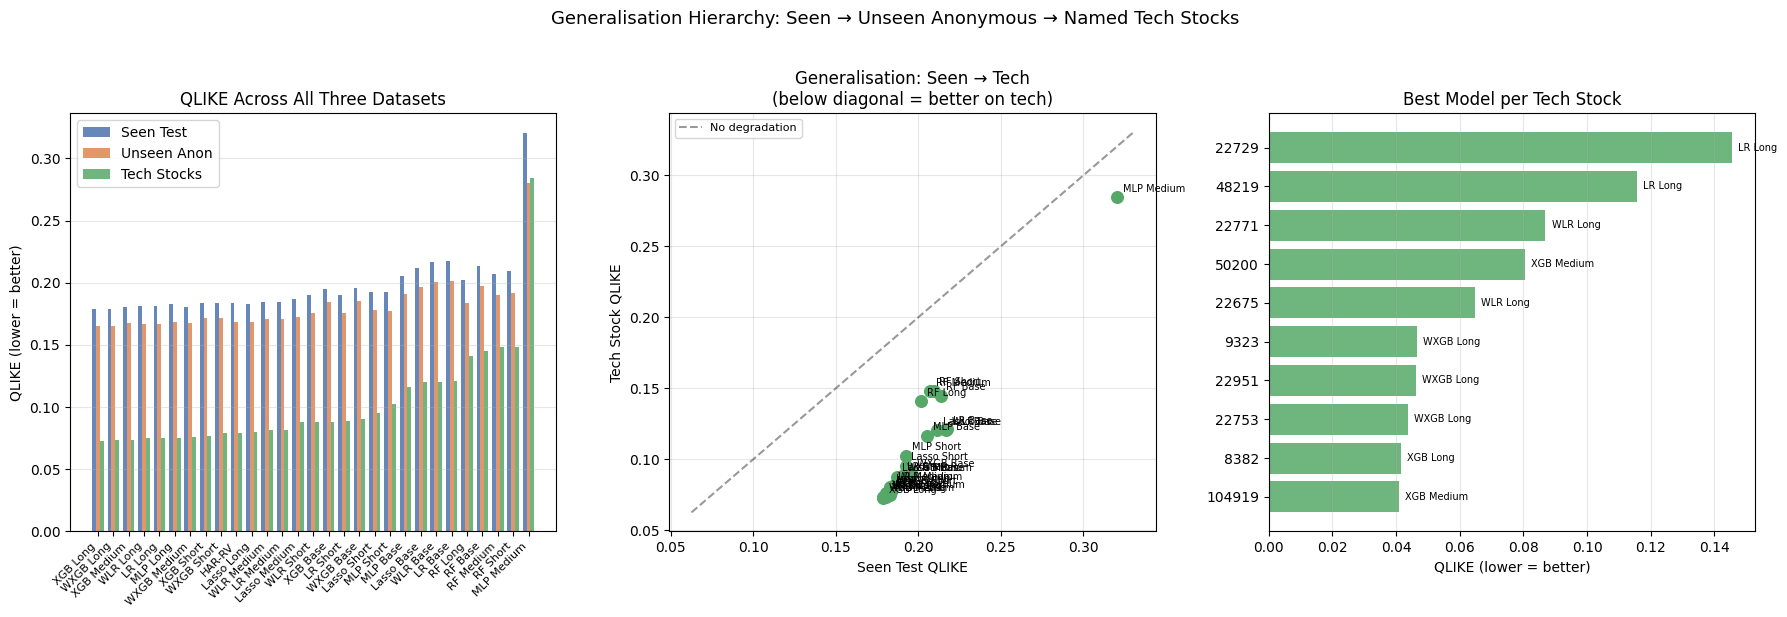

✓ Saved three_way_comparison.png


In [ ]:

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Load previously saved results 
seen_results   = joblib.load('models/results_dict.joblib')    # from Notebook 2
unseen_results = joblib.load('models/unseen_results.joblib')  # from Notebook 2
tech_results   = joblib.load('models/tech_results_per_stock.joblib')    # saved in Cell 5

# Compute average tech results across stocks from the per-stock CSV
tech_per_stock = pd.read_csv('models/tech_per_stock_all_models.csv')
tech_avg = (
    tech_per_stock.groupby('model')[['rmse','rmspe','qlike']]
    .mean()
    .rename(columns={'rmse':'rmse','rmspe':'rmspe','qlike':'qlike'})
)

#  Models that exist in all three result sets ─────────────────────────────────
common_models = [k for k in seen_results if k in unseen_results and k in tech_avg.index]
print(f"Models in all three sets: {len(common_models)}")
print(common_models)

#  Build comparison DataFrame ────────────────────────────────────────────────
rows = []
for model in common_models:
    rows.append({
        'model'        : model,
        'seen_qlike'   : seen_results[model]['qlike'],
        'unseen_qlike' : unseen_results[model]['qlike'],
        'tech_qlike'   : tech_avg.loc[model, 'qlike'],
        'seen_rmspe'   : seen_results[model]['rmspe'],
        'unseen_rmspe' : unseen_results[model]['rmspe'],
        'tech_rmspe'   : tech_avg.loc[model, 'rmspe'],
    })

comparison = pd.DataFrame(rows).sort_values('tech_qlike').reset_index(drop=True)

#  Print three-way table ─────────────────────────────────────────────────────
print(f"\n── Three-Way QLIKE Comparison ───────────────────────────────────────────")
print(f"  {'Model':<22}  {'Seen Test':>10}  {'Unseen Anon':>12}  {'Tech Stocks':>12}  {'Δ Tech-Seen':>12}")
print("─" * 76)
for _, row in comparison.iterrows():
    delta = row['tech_qlike'] - row['seen_qlike']
    print(f"  {row['model']:<22}  {row['seen_qlike']:>10.4f}  "
          f"{row['unseen_qlike']:>12.4f}  {row['tech_qlike']:>12.4f}  "
          f"{delta:>+12.4f}")

#  Plot 
good_models = comparison[comparison['tech_qlike'] < 1.0].copy()

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig)

colors = {'Seen Test': '#4C72B0', 'Unseen Anon': '#DD8452', 'Tech Stocks': '#55A868'}

# Plot 1: Bar chart — QLIKE across three datasets 
ax1  = fig.add_subplot(gs[0])
x    = np.arange(len(good_models))
w    = 0.25

ax1.bar(x - w,   good_models['seen_qlike'],   w, label='Seen Test',   color=colors['Seen Test'],   alpha=0.85)
ax1.bar(x,       good_models['unseen_qlike'], w, label='Unseen Anon', color=colors['Unseen Anon'], alpha=0.85)
ax1.bar(x + w,   good_models['tech_qlike'],   w, label='Tech Stocks', color=colors['Tech Stocks'], alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(good_models['model'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('QLIKE (lower = better)')
ax1.set_title('QLIKE Across All Three Datasets')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Generalisation scatter — Seen vs Tech 
ax2 = fig.add_subplot(gs[1])
ax2.scatter(good_models['seen_qlike'], good_models['tech_qlike'],
            color=colors['Tech Stocks'], s=70, zorder=3)
for _, row in good_models.iterrows():
    ax2.annotate(row['model'], (row['seen_qlike'], row['tech_qlike']),
                 fontsize=7, xytext=(4, 4), textcoords='offset points')
lim_min = min(good_models['seen_qlike'].min(), good_models['tech_qlike'].min()) - 0.01
lim_max = max(good_models['seen_qlike'].max(), good_models['tech_qlike'].max()) + 0.01
ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.4, label='No degradation')
ax2.set_xlabel('Seen Test QLIKE')
ax2.set_ylabel('Tech Stock QLIKE')
ax2.set_title('Generalisation: Seen → Tech\n(below diagonal = better on tech)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Plot 3: Per-stock best model QLIKE 
ax3 = fig.add_subplot(gs[2])
best_per_stock = (
    tech_per_stock[tech_per_stock['qlike'] < 1.0]
    .sort_values('qlike')
    .groupby('stock_id')
    .first()
    .reset_index()[['stock_id', 'model', 'qlike']]
    .sort_values('qlike')
)

bar_colors = [colors['Tech Stocks']] * len(best_per_stock)
bars = ax3.barh(best_per_stock['stock_id'].astype(str),
                best_per_stock['qlike'],
                color=bar_colors, alpha=0.85)

# Annotate with best model name
for bar, (_, row) in zip(bars, best_per_stock.iterrows()):
    ax3.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             row['model'], va='center', fontsize=7)

ax3.set_xlabel('QLIKE (lower = better)')
ax3.set_title('Best Model per Tech Stock')
ax3.grid(axis='x', alpha=0.3)

plt.suptitle('Generalisation Hierarchy: Seen → Unseen Anonymous → Named Tech Stocks',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('models/three_way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved three_way_comparison.png")

In [ ]:
import joblib
import pandas as pd

# Check what keys exist in the seen and unseen results
seen_results   = joblib.load('models/results_dict.joblib')
unseen_results = joblib.load('models/unseen_results.joblib')

print("Keys in seen_results:")
for k, v in seen_results.items():
    print(f"  {k:<22}  qlike={v['qlike']:.6f}")

print(f"\nKeys in unseen_results:")
for k, v in unseen_results.items():
    print(f"  {k:<22}  qlike={v['qlike']:.6f}")

print(f"\nTech per-stock CSV:")
tech_per_stock = pd.read_csv('models/tech_per_stock_all_models.csv')
print(tech_per_stock.head())
print(f"Columns: {list(tech_per_stock.columns)}")
print(f"Models: {sorted(tech_per_stock['model'].unique())}")

Keys in seen_results:
  LR Base                 qlike=0.217463
  LR Short                qlike=0.190087
  LR Medium               qlike=0.184700
  LR Long                 qlike=0.181288
  Lasso Base              qlike=0.211676
  Lasso Short             qlike=0.192527
  Lasso Medium            qlike=0.187061
  Lasso Long              qlike=0.183051
  XGB Base                qlike=0.195131
  XGB Short               qlike=0.183397
  XGB Medium              qlike=0.180393
  XGB Long                qlike=0.178809
  RF Base                 qlike=0.213748
  RF Short                qlike=0.209477
  RF Medium               qlike=0.207271
  RF Long                 qlike=0.201957
  MLP Base                qlike=0.205506
  MLP Short               qlike=0.192633
  MLP Medium              qlike=0.320451
  MLP Long                qlike=0.182709
  EWMA                    qlike=0.270585
  HAR-RV                  qlike=0.184091
  WLR Base                qlike=0.217086
  WLR Short               qlike=0.1

Common models: 29

── Three-Way QLIKE Comparison (sorted by Tech QLIKE) ───────────────────
  Model                    Seen Test   Unseen Anon   Tech Stocks   Δ Tech-Seen
────────────────────────────────────────────────────────────────────────────
  XGB Long                    0.1788        0.1649        0.0727       -0.1061  ✓
  WXGB Long                   0.1789        0.1649        0.0738       -0.1051  ✓
  XGB Medium                  0.1804        0.1679        0.0738       -0.1066  ✓
  WLR Long                    0.1813        0.1666        0.0751       -0.1062  ✓
  LR Long                     0.1813        0.1666        0.0752       -0.1061  ✓
  MLP Long                    0.1827        0.1687        0.0753       -0.1074  ✓
  WXGB Medium                 0.1806        0.1679        0.0761       -0.1044  ✓
  XGB Short                   0.1834        0.1716        0.0767       -0.1067  ✓
  WXGB Short                  0.1837        0.1718        0.0788       -0.1049  ✓
  HAR-RV      

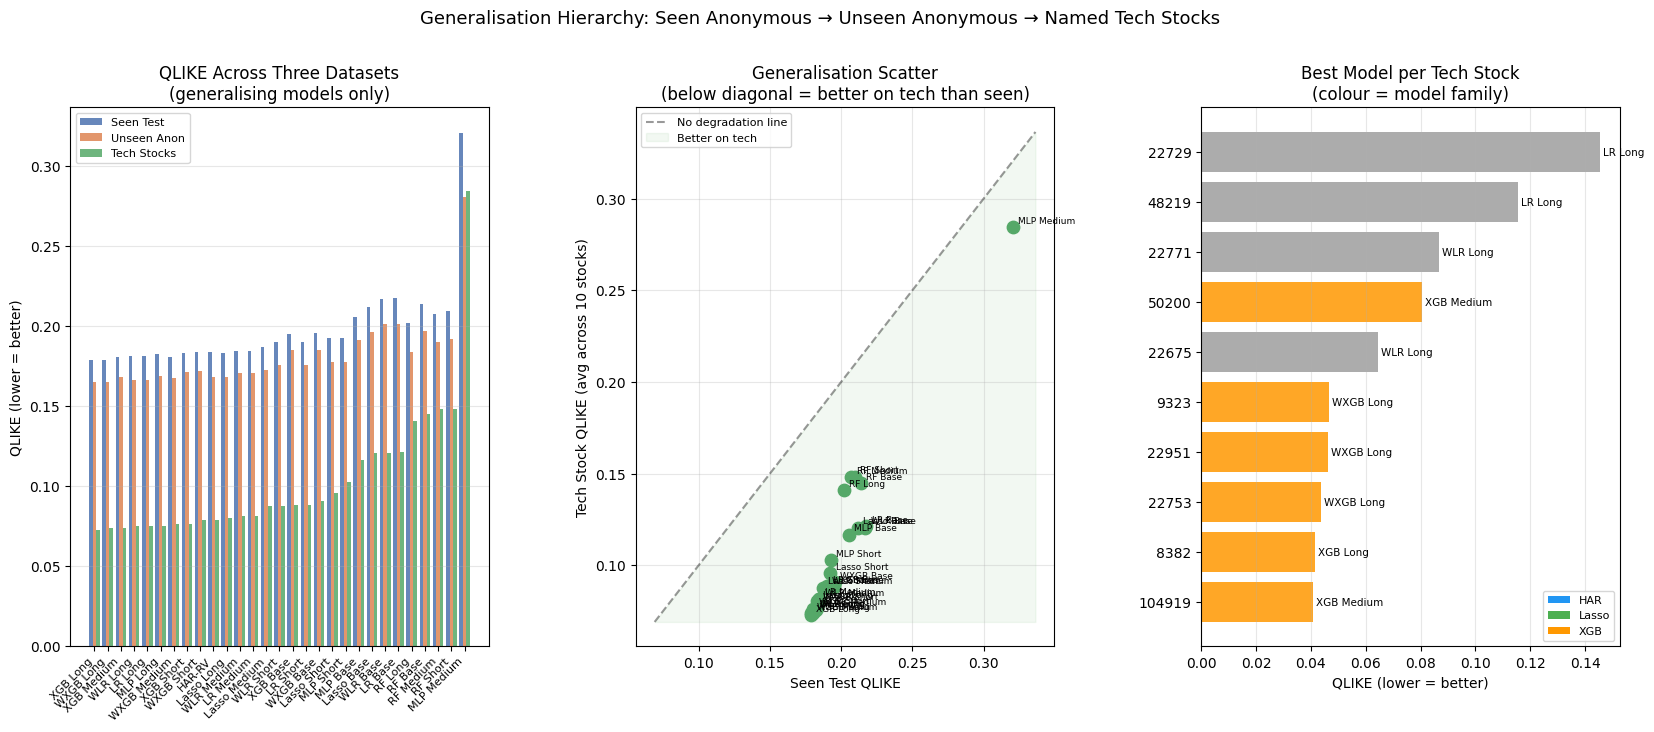

✓ Saved three_way_comparison.png


In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Compute average tech QLIKE per model across all 10 stocks 
tech_avg = (
    tech_per_stock.groupby('model')[['rmse', 'rmspe', 'qlike']]
    .mean()
    .reset_index()
)

#  Find models common to all three 
seen_keys   = set(seen_results.keys()) - {'EWMA'}   # drop EWMA, not in others
unseen_keys = set(unseen_results.keys())
tech_keys   = set(tech_avg['model'].unique())
common      = seen_keys & unseen_keys & tech_keys

print(f"Common models: {len(common)}")

#  Build comparison table ────────────────────────────────────────────────────
rows = []
for model in common:
    t_row = tech_avg[tech_avg['model'] == model].iloc[0]
    rows.append({
        'model'        : model,
        'seen_qlike'   : seen_results[model]['qlike'],
        'unseen_qlike' : unseen_results[model]['qlike'],
        'tech_qlike'   : t_row['qlike'],
        'seen_rmspe'   : seen_results[model]['rmspe'],
        'unseen_rmspe' : unseen_results[model]['rmspe'],
        'tech_rmspe'   : t_row['rmspe'],
    })

comparison = pd.DataFrame(rows).sort_values('tech_qlike').reset_index(drop=True)

#  Print three-way table 
print(f"\n── Three-Way QLIKE Comparison (sorted by Tech QLIKE) ───────────────────")
print(f"  {'Model':<22}  {'Seen Test':>10}  {'Unseen Anon':>12}  {'Tech Stocks':>12}  {'Δ Tech-Seen':>12}")
print("─" * 76)
for _, row in comparison.iterrows():
    delta = row['tech_qlike'] - row['seen_qlike']
    flag  = '✓' if row['tech_qlike'] < row['seen_qlike'] else ''
    print(f"  {row['model']:<22}  {row['seen_qlike']:>10.4f}  "
          f"{row['unseen_qlike']:>12.4f}  {row['tech_qlike']:>12.4f}  "
          f"{delta:>+12.4f}  {flag}")

# Separate good models (QLIKE < 1) from failed ones 
good = comparison[comparison['tech_qlike'] < 1.0].copy().reset_index(drop=True)
bad  = comparison[comparison['tech_qlike'] >= 1.0].copy().reset_index(drop=True)
print(f"\nModels that generalised (QLIKE < 1) : {len(good)}")
print(f"Models that failed (QLIKE >= 1)     : {len(bad)}")
print(f"Failed models: {bad['model'].tolist()}")

#  Plot 
fig = plt.figure(figsize=(20, 7))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

c_seen   = '#4C72B0'
c_unseen = '#DD8452'
c_tech   = '#55A868'

# Panel 1: Grouped bar chart — good models only 
ax1 = fig.add_subplot(gs[0])
x   = np.arange(len(good))
w   = 0.27

b1 = ax1.bar(x - w,   good['seen_qlike'],   w, label='Seen Test',   color=c_seen,   alpha=0.85)
b2 = ax1.bar(x,       good['unseen_qlike'], w, label='Unseen Anon', color=c_unseen, alpha=0.85)
b3 = ax1.bar(x + w,   good['tech_qlike'],   w, label='Tech Stocks', color=c_tech,   alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(good['model'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('QLIKE (lower = better)')
ax1.set_title('QLIKE Across Three Datasets\n(generalising models only)')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

#  Panel 2: Scatter — Seen Test vs Tech 
ax2 = fig.add_subplot(gs[1])
ax2.scatter(good['seen_qlike'], good['tech_qlike'],
            color=c_tech, s=80, zorder=3)
for _, row in good.iterrows():
    ax2.annotate(row['model'],
                 (row['seen_qlike'], row['tech_qlike']),
                 fontsize=6.5, xytext=(4, 3), textcoords='offset points')

lim_min = min(good['seen_qlike'].min(), good['tech_qlike'].min()) * 0.95
lim_max = max(good['seen_qlike'].max(), good['tech_qlike'].max()) * 1.05
ax2.plot([lim_min, lim_max], [lim_min, lim_max],
         'k--', alpha=0.4, label='No degradation line')
ax2.fill_between([lim_min, lim_max], [lim_min, lim_min], [lim_min, lim_max],
                 alpha=0.05, color='green', label='Better on tech')
ax2.set_xlabel('Seen Test QLIKE')
ax2.set_ylabel('Tech Stock QLIKE (avg across 10 stocks)')
ax2.set_title('Generalisation Scatter\n(below diagonal = better on tech than seen)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

#  Panel 3: Per-stock best model QLIKE 
ax3 = fig.add_subplot(gs[2])
best_per_stock = (
    tech_per_stock[tech_per_stock['qlike'] < 1.0]
    .sort_values('qlike')
    .groupby('stock_id')
    .first()
    .reset_index()[['stock_id', 'model', 'qlike']]
    .sort_values('qlike', ascending=True)
)

# Colour bars by winning model family
family_colors = {
    'HAR'  : '#2196F3',
    'Lasso': '#4CAF50',
    'XGB'  : '#FF9800',
}
def bar_color(model_name):
    for k, v in family_colors.items():
        if k in model_name:
            return v
    return '#9E9E9E'

bar_cols = [bar_color(m) for m in best_per_stock['model']]
bars = ax3.barh(
    best_per_stock['stock_id'].astype(str),
    best_per_stock['qlike'],
    color=bar_cols, alpha=0.85
)
for bar, (_, row) in zip(bars, best_per_stock.iterrows()):
    ax3.text(bar.get_width() + 0.001,
             bar.get_y() + bar.get_height() / 2,
             row['model'], va='center', fontsize=7.5)

# Legend for bar colours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in family_colors.items()]
ax3.legend(handles=legend_elements, fontsize=8, loc='lower right')
ax3.set_xlabel('QLIKE (lower = better)')
ax3.set_title('Best Model per Tech Stock\n(colour = model family)')
ax3.grid(axis='x', alpha=0.3)

plt.suptitle(
    'Generalisation Hierarchy: Seen Anonymous → Unseen Anonymous → Named Tech Stocks',
    fontsize=13, y=1.02
)
plt.savefig('models/three_way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved three_way_comparison.png")